# Анализ тональности аспектов для вручную размеченного датасета #

### Предобработка данных для отделения тональности аспектов ###

После разметки исходная таблица содержала следующие столбцы: текст отзыва, общая тональность, аспекты, тональность аспектов. В случае наличия в отзыва нескольких аспектов, они перечислялись в одном столбце через запятую, как и их тональности. Поэтому предобратотка включала себя следующие шаги:   

    1. Отброс столбцов "текст отзыва" и "общая тональность"   
    
    2. Разделения аспектов на отдельные строки в таблице (один аспект = одна строка)   
    

In [ ]:
import pandas as pd

df = pd.read_excel("datasets\Review_and_aspects.xlsx")
df = df[["Аспекты", "Тональности аспектов"]]

#Разделение строк с несколькими аспектами
rows = []
for _, row in df.iterrows():
    aspects = str(row["Аспекты"]).split(",")
    sentiments = str(row["Тональности аспектов"]).split(",")
    
    
    length = min(len(aspects), len(sentiments))
    for i in range(length):
        aspect = aspects[i].strip()
        sentiment = sentiments[i].strip()
        if aspect:  
            rows.append({"Аспект": aspect, "Тональность": sentiment})

new_df = pd.DataFrame(rows)
output_path = "datasets\Aspects_and_sentiments_separated.xlsx"
new_df.to_excel(output_path, index=False)

### Подсчёт количества вхождений каждого аспекта в позитивном, негативной и нейтральном ключе ###

После разделения аспектов на отдельные строки необходимо было определить сколько раз каждый аспект встечался в положительном, нейтральном и негативном ключе. 

In [ ]:
import pandas as pd

df = pd.read_excel("datasets\Aspects_and_sentiments_separated.xlsx")

# df.columns = [col.strip() for col in df.columns]  
# assert "Аспект" in df.columns and "Тональность" in df.columns, "Проверь названия столбцов!"

# Подсчёт количества каждой тональности для каждого аспекта 
pivot_df = (
    df.groupby(["Аспект", "Тональность"])
      .size()
      .unstack(fill_value=0) 
      .reset_index()
)

# Добавление отсутствующих столбцов
for sentiment in ["Pos", "Neu", "Neg"]:
    if sentiment not in pivot_df.columns:
        pivot_df[sentiment] = 0

pivot_df = pivot_df[["Аспект", "Pos", "Neu", "Neg"]]

output_path = "datasets\Aspect_sentiment_counts.xlsx"
pivot_df.to_excel(output_path, index=False)

### Лемматизация и сокращение колличества аспектов ###

Полученная на предыдущем шаге таблица содержала вхождение одних и тех же слов в разных формах. Например: врач, врачу, врачи, врачам. Для объединения разных форм слова в один аспект была проведена лемматизация.    

Лемматизация — это процесс приведения словоформы к её базовой, словарной форме, или «лемме». Цель: Снизить вариативность слов и упростить их анализ, так как компьютер «понимает» все эти формы как одно и то же слово.

В результате статистика по формам одного и того же слова была собрана вместе.

In [ ]:
import pandas as pd
from pymorphy2 import MorphAnalyzer

df = pd.read_excel("datasets\Aspect_sentiment_counts.xlsx")

morph = MorphAnalyzer()

def lemmatize_word(word: str) -> str:
    word = word.lower().strip()
    if not word:
        return word
    # Берём первую нормальную форму (лемму)
    p = morph.parse(word)[0]
    return p.normal_form

# Применение лемматизации к аспектам
df["Лемма"] = df["Аспект"].astype(str).apply(lemmatize_word)

# Группировка по лемме и суммирование тональностей
grouped = (
    df.groupby("Лемма")[["Pos", "Neu", "Neg"]]
      .sum()
      .reset_index()
      .rename(columns={"Лемма": "Аспект"})
)


grouped.to_excel("datasets\Aspect_sentiment_lemmatized.xlsx", index=False)



### Избавление от редко встречающихся аспектов ###

После объединения разных форм слова, вручную были переопределены некоторые аспекты. Например, профессии хирург, эндокринолог, терапевт и др. были отнесены к аспекут врач. Таким образом некотрые редко встревающиеся аспекты вошли в более крупные и часто встречаемые.   

Аспекты, которые упоминались единожды и не могли быть отнесенны в какую-то более крупную категорию, было решено убрать из данных для анализа, поскольку они не вносили существенный вклад в статистику.

In [ ]:
import pandas as pd

df = pd.read_excel('datasets\Aspect_sentiment_lemmatized.xlsx')

# Избавление от строк, где сумма Pos + Neu + Neg = 1
df_filtered = df[df['Pos'] + df['Neu'] + df['Neg'] != 1]


df_filtered.to_excel('datasets\Aspect_sentiment_filtered.xlsx', index=False)

### Построение графиков ###

Для отображения получившейся статистики строим график позитивных, нейтральных и негативных оценок для 10 самых популярынх аспектов.  

Топ-10 аспектов:
    Аспект  Pos  Neu  Neg  Total
      врач  614   41   34    689
  персонал  363    6   19    388
  больница  231   59   17    307
 отношение   83    0   15     98
 отделение   48   40    4     92
   лечение   39   23    3     65
  операция   55    4    2     61
заведующий   31    2    3     36
     приём   11    7   16     34
   очередь   13    1   16     30


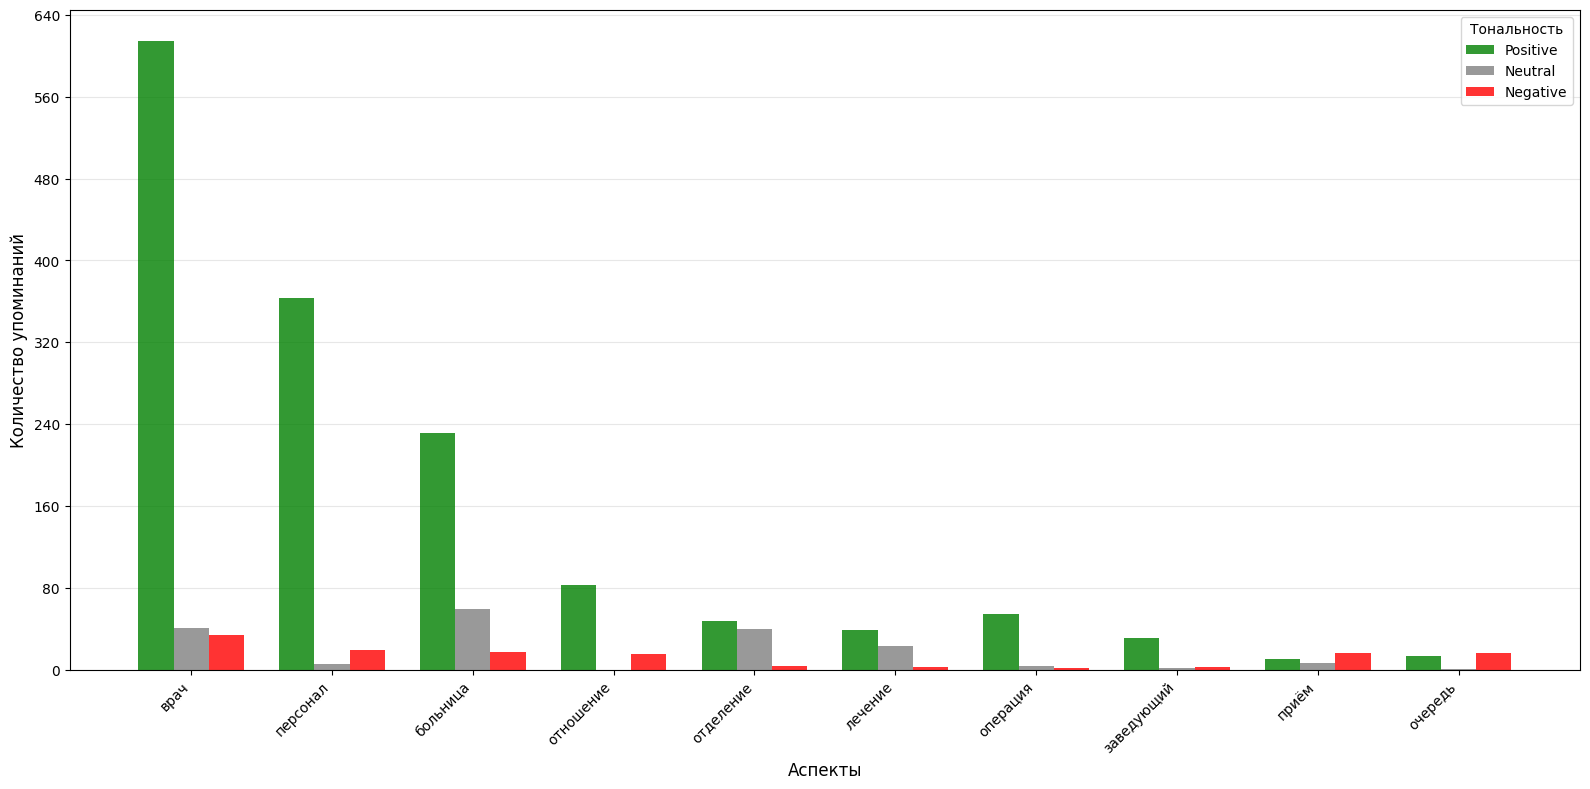

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('datasets\Aspect_sentiment_filtered.xlsx')

df['Total'] = df['Pos'] + df['Neu'] + df['Neg']
top_aspects = df.nlargest(10, 'Total')


plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 8))


colors = ['green', 'gray', 'red']  

x = np.arange(len(top_aspects))
width = 0.25  

# Создание столбцов для каждого типа sentiment
bars_pos = ax.bar(x - width, top_aspects['Pos'], width, 
                 label='Positive', color=colors[0], alpha=0.8)
bars_neu = ax.bar(x, top_aspects['Neu'], width, 
                 label='Neutral', color=colors[1], alpha=0.8)
bars_neg = ax.bar(x + width, top_aspects['Neg'], width, 
                 label='Negative', color=colors[2], alpha=0.8)

# Настройка осей и заголовка
ax.set_ylabel('Количество упоминаний', fontsize=12)
ax.set_xlabel('Аспекты', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(top_aspects['Аспект'], rotation=45, ha='right')

ax.legend(title='Тональность')

ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()

plt.show()

plt.savefig('top_aspects_sentiment_grouped.png', dpi=300, bbox_inches='tight')

# print("Топ-10 аспектов:")
# print(top_aspects[['Аспект', 'Pos', 'Neu', 'Neg', 'Total']].to_string(index=False))

Имеющиеся аспекты делим по категориям:   

    - отношение к врачу;  
    
    - отношение к записи и времени ожидания;  
    
    - отношение к качеству лечения;  
    
    - отношение к организации;
    
    - отношение к пациенту;
    
    - отношение к персоналу;
    
    - отношение к услевиям мед. учреждения.

И считаем общую тональность для каждой получившейся категории.

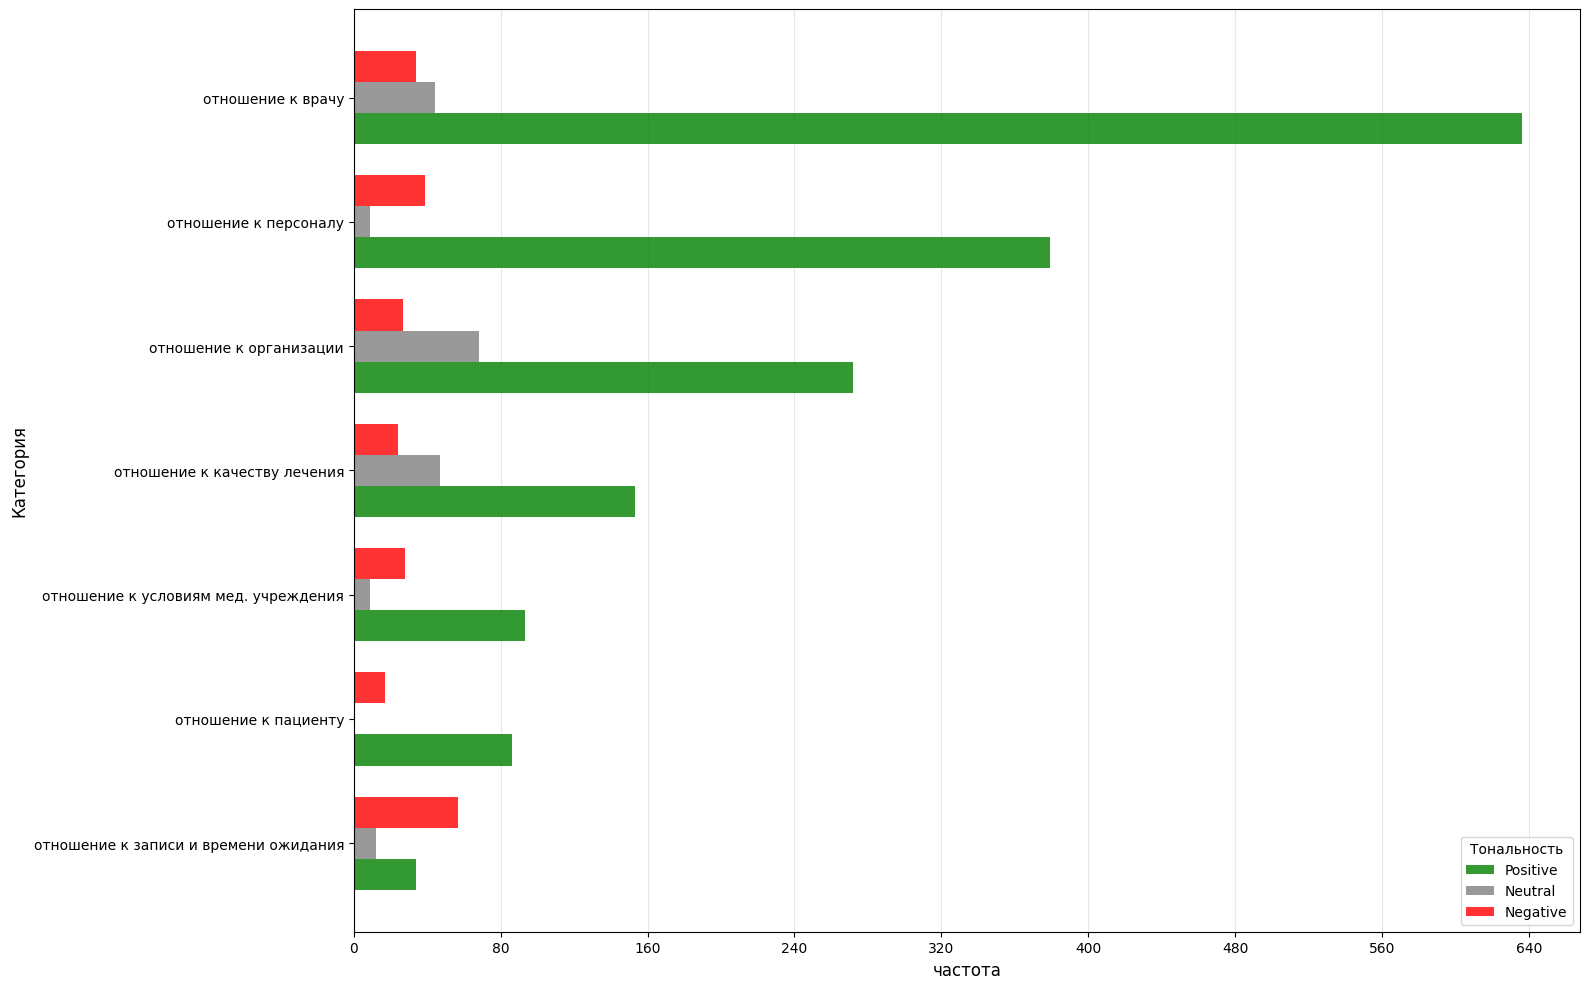

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_excel('datasets\Aspect_sentiment_filtered.xlsx')

df['Total'] = df['Pos'] + df['Neu'] + df['Neg']

categories = {
    'отношение к врачу': ['врач', 'вреач', 'завотделение', 'профессионализм', 'хирургия', 'терапия', 'неврология', 'ортопедия', 'урология', 'гинекология'],
    'отношение к записи и времени ожидания': ['запись', 'время', 'ожидание', 'очередь', 'запись по телефон', 'срок', 'задержка', 'опоздание', 'час', 'направление', 'приём', 'приëм'],
    'отношение к качеству лечения': ['лечение', 'диагноз', 'операция', 'диагностика', 'обследование', 'анализ', 'помощь', 'результат', 'анестезия', 'исследование', 'реанимация', 'диспансеризация', 'консультация', 'подход', 'лечиться'],
    'отношение к организации': ['организация', 'администрация', 'руководство', 'заведовать', 'учреждение', 'центр', 'больница', 'больгиц', 'больгница', 'гкб', 'госпиталь', 'медцентр', 'стационар',  'платно', 'платные услуга', 'бесплатно', 'оплата', 'стоимость', 'цена', 'деньга', 'полис'],
    'отношение к пациенту': ['отношение', 'внимание', 'подход', 'общение', 'клиентоориентированность', 'пациент', 'обращение', 'рекомендация'],
    'отношение к персоналу': ['персонал', 'мед персонал', 'коллега', 'регистратура', 'оператор', 'гардеробщик', 'бригада', 'практикант', 'коллектив', 'медицина', 'кадра', 'ординатура'],
    'отношение к условиям мед. учреждения': ['палата', 'оборудование', 'здание', 'территория', 'чистота', 'корпус', 'коридор', 'туалет',  'парковка', 'ремонт', 'аппаратура', 'техника', 'технология', 'мебель', 'кровать', 'бельё', 'условие', 'удобство', 'неудобный', 'атмосфера', 'обстановка', 'места общего пользование', 'вход', 'двор', 'парк', 'гардероб', 'буфет', 'кабинет', 'кафе', 'окно', 'лестница', 'лифт', 'поручень', 'кондиционер',  'навигация', 'планировка',   'одноразовых пелёнка', 'перчатка', 'еда', 'питание', 'кормить', 'трапезный',  'холл', 'вестибюль',  'мусор', 'чистота', 'санузел', 'ванна', 'душ', 'туалет', 'уборная']
}

# Функция для определения категории аспекта
def get_category(aspect):
    for category, aspects_list in categories.items():
        if aspect in aspects_list:
            return category
    return 'другое'

df['Category'] = df['Аспект'].apply(get_category)

# Группируем по категориям и суммируем значения
category_totals = df.groupby('Category').agg({
    'Pos': 'sum',
    'Neu': 'sum', 
    'Neg': 'sum',
    'Total': 'sum'
}).reset_index()

category_totals = category_totals[category_totals['Category'] != 'другое']

category_totals = category_totals.sort_values('Total', ascending=True)

plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 10))

colors = ['green', 'gray', 'red'] 

y = np.arange(len(category_totals))
height = 0.25  

# Создаем горизонтальные столбцы для каждого типа sentiment
bars_pos = ax.barh(y - height, category_totals['Pos'], height, 
                  label='Positive', color=colors[0], alpha=0.8)
bars_neu = ax.barh(y, category_totals['Neu'], height, 
                  label='Neutral', color=colors[1], alpha=0.8)
bars_neg = ax.barh(y + height, category_totals['Neg'], height, 
                  label='Negative', color=colors[2], alpha=0.8)

ax.set_xlabel('частота', fontsize=12)
ax.set_ylabel('Категория', fontsize=12)

ax.set_yticks(y)
ax.set_yticklabels(category_totals['Category'])

ax.legend(title='Тональность', loc='lower right')

ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)


ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


plt.tight_layout()

plt.show()


plt.savefig('category_sentiment_horizontal.png', dpi=300, bbox_inches='tight')

# print("Сумма по категориям:")
# print(category_totals.to_string(index=False))

# print("\nАспекты по категориям:")
# for category in categories.keys():
#     aspects_in_category = df[df['Category'] == category]['Аспект'].tolist()
#     print(f"{category}: {', '.join(aspects_in_category)}")